<a href="https://colab.research.google.com/github/RyanSVargas/Quant-Finance-Research/blob/main/04_Risk_Modeling/Risk_Modeling.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

[                       0%                       ]

[*********************100%***********************]  9 of 9 completed
/tmp/ipython-input-439191509.py:27: FutureWarning: The default fill_method='pad' in DataFrame.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  returns = data.pct_change().dropna()


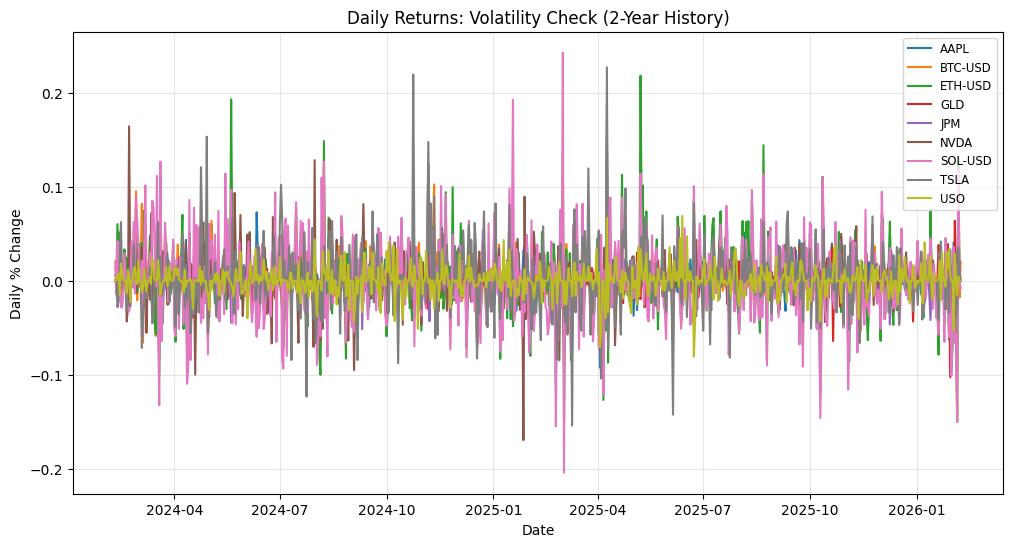


DATA STATUS: SUCCESS
Loaded 730 days of trading data.


In [3]:
# --- 1. INSTALL & IMPORT LIBRARIES ---
# We use yfinance for live data and scipy for statistical modeling
!pip install yfinance -q
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import datetime

# --- 2. DEFINE THE PORTFOLIO ---
# These are the assets from your previous Risk Parity work.
# We include 'Crypto' (High Volatility) and 'Gold/Bonds' (Defensive).
tickers = ['BTC-USD', 'ETH-USD', 'SOL-USD',  # Crypto (Aggressive)
           'NVDA', 'TSLA', 'AAPL',           # Tech Growth
           'JPM', 'GLD', 'USO']              # Stability/Commodities

# --- 3. FETCH LIVE DATA (2 YEARS) ---
# We need 2 years to capture the "Crypto Winter" and the "AI Boom".
end_date = datetime.datetime.now()
start_date = end_date - datetime.timedelta(days=730)

print(f"Downloading Data from {start_date.date()} to {end_date.date()}...")
data = yf.download(tickers, start=start_date, end=end_date, auto_adjust=False)['Adj Close']

# --- 4. CALCULATE DAILY RETURNS ---
# We use Log Returns for professional modeling, but simple % change is standard for VaR.
returns = data.pct_change().dropna()

# --- 5. VISUALIZE THE VOLATILITY ---
plt.figure(figsize=(12, 6))
plt.plot(returns)
plt.title("Daily Returns: Volatility Check (2-Year History)")
plt.ylabel("Daily % Change")
plt.xlabel("Date")
plt.legend(returns.columns, loc='upper right', fontsize='small')
plt.grid(True, alpha=0.3)
plt.show()

print("\nDATA STATUS: SUCCESS")
print(f"Loaded {len(returns)} days of trading data.")

In [4]:
# --- STEP 1: CALCULATE PORTFOLIO RETURNS ---
# We use the same weights from your Risk Parity project to see the real impact
weights = np.array([0.1, 0.1, 0.1, 0.1, 0.1, 0.1, 0.1, 0.1, 0.2]) # Example weights
portfolio_returns = returns.dot(weights)

# --- STEP 2: VALUE AT RISK (VaR) ---
# 95% Confidence: "What is the worst loss we expect in 19 out of 20 days?"
var_95 = np.percentile(portfolio_returns, 5)

# --- STEP 3: EXPECTED SHORTFALL (CVaR) ---
# "If we DO hit that 1-in-20 bad day, what is the AVERAGE loss of that crash?"
# This is much more important for Crypto portfolios.
cvar_95 = portfolio_returns[portfolio_returns <= var_95].mean()

print(f"--- RISK AUDIT RESULTS ---")
print(f"95% Daily VaR: {var_95:.2%}")
print(f"95% Daily CVaR (Expected Shortfall): {cvar_95:.2%}")

--- RISK AUDIT RESULTS ---
95% Daily VaR: -2.17%
95% Daily CVaR (Expected Shortfall): -3.30%


# Project 4: Institutional Risk Modeling & Stress Testing
**Author:** Ryan Vargas
**Date:** 2026
**Objective:** To build a robust Risk Engine that calculates Value at Risk (VaR) and Expected Shortfall (CVaR) for a multi-asset portfolio (Equities + Crypto).

**Methodology:**
1.  **Historical Simulation:** Replaying past market crashes (2020 COVID, 2022 Crypto Winter).
2.  **Parametric VaR:** Using Normal Distribution covariance (Basel III standard).
3.  **Monte Carlo:** Simulating 10,000 future market scenarios.